<a href="https://colab.research.google.com/github/jsoteloflores/KilaueaFountainSegmentation/blob/main/lava_fountain_segmentation_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kilauea Lava Fountain Segmentation — Single-File Colab Training Script

Train a **binary segmentation model** that maps an RGB ROI image to a binary mask of
**visible airborne incandescent lava fountain material** inside the target-fountain
analysis ROI.

```text
Positive : visible airborne incandescent lava fountain material inside the ROI
Negative : everything else inside the ROI
Outside ROI : ignored (not positive, not negative)
```

This is **one self-contained script/notebook**. Run it top to bottom. All settings live in
the `CONFIG` dictionary in Section 3.

**Supported workflow (active-learning loop):**
1. Label ~95 frames in FountainLabeller.
2. Upload the dataset folder to Google Drive / Colab.
3. Run this script.
4. Watch the live training graph update each epoch.
5. Save the best model + full run package.
6. Run inference on all frames (and any new frames).
7. Export predicted masks at original ROI size.
8. Refine masks in FountainLabeller, add frames, retrain.

**Sections**
1. Setup / installs · 2. Imports · 3. User config · 4. Dataset discovery & validation ·
5. Split generation/loading · 6. Preprocessing (aspect-preserving resize + pad) ·
7. Dataset & dataloaders · 8. Model · 9. Losses & metrics · 10. Live plotting ·
11. Training loop · 12. Validation/test evaluation · 13. Threshold sweep ·
14. Save model package · 15. Inference on all frames · 16. Export masks/overlays.

## 1. Setup / installs

Installs run only inside Colab. Locally, install the same packages into your environment:
`pip install torch torchvision segmentation-models-pytorch albumentations opencv-python pandas matplotlib`.

In [1]:
import importlib
import subprocess
import sys


def _in_colab() -> bool:
    return "google.colab" in sys.modules or importlib.util.find_spec("google.colab") is not None


IN_COLAB = _in_colab()


def _pip_install(*packages: str) -> None:
    cmd = [sys.executable, "-m", "pip", "install", "-q", *packages]
    print("Installing:", " ".join(packages))
    subprocess.run(cmd, check=False)


def _ensure_packages() -> None:
    """Install required third-party packages if they are missing."""
    needed = []
    for module_name, pip_name in [
        ("segmentation_models_pytorch", "segmentation-models-pytorch"),
        ("albumentations", "albumentations"),
        ("cv2", "opencv-python-headless"),
    ]:
        if importlib.util.find_spec(module_name) is None:
            needed.append(pip_name)
    if needed:
        _pip_install(*needed)
    else:
        print("All required packages already installed.")


# Only auto-install in Colab to avoid touching local/managed environments unexpectedly.
if IN_COLAB:
    _ensure_packages()
else:
    print("Not running in Google Colab. Skipping auto-install.")
    print("Ensure these are installed: torch torchvision segmentation-models-pytorch "
          "albumentations opencv-python pandas matplotlib")

Installing: segmentation-models-pytorch


## 2. Imports

In [2]:
import csv
import json
import math
import os
import random
import shutil
import time
from dataclasses import dataclass, field
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt
from IPython.display import clear_output, display

import albumentations as A
import segmentation_models_pytorch as smp

# cv2 in dataloader worker processes should not spawn its own threads.
cv2.setNumThreads(0)

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


## 3. User config

Edit `dataset_root`, `run_root`, `input_size`, and `batch_size` for your environment.

- `mode`: one of `train`, `resume_train`, `infer_all`, `evaluate`.
- `input_size`: 768 (debug) / 1536 (recommended) / 2048 (A100).
- `checkpoint_path`: required for `resume_train`, `infer_all`, and `evaluate`.

In [4]:
CONFIG: Dict = {
    # --- Paths ---
    "dataset_root": "/content/drive/MyDrive/MLData",
    "run_root": "/content/drive/MyDrive/lava_fountain_runs",
    "mount_drive": True,  # mount Google Drive when running in Colab

    # --- Mode ---
    "mode": "train",  # train | resume_train | infer_all | evaluate

    # --- Image sizes ---
    "input_size": 1536,
    "debug_input_size": 768,
    "large_input_size": 2048,

    # --- Training ---
    "batch_size": 2,
    "num_epochs": 50,
    "early_stopping_patience": 10,
    "num_workers": 2,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "bce_weight": 1.0,
    "dice_weight": 1.0,
    "use_amp": True,
    "grad_accum_steps": 1,
    "scheduler": "plateau",  # plateau | cosine
    "monitor_metric": "val_dice",  # val_dice (maximize) | val_loss (minimize)
    "seed": 42,

    # --- Model ---
    "model_name": "Unet",
    "encoder_name": "efficientnet-b3",
    "encoder_weights": "imagenet",
    "in_channels": 3,
    "classes": 1,

    # --- Thresholds ---
    "threshold": 0.5,
    "threshold_sweep": [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50,
                        0.55, 0.60, 0.65, 0.70, 0.75, 0.80],

    # --- Augmentation ---
    "augment": True,
    "horizontal_flip": False,

    # --- Split ---
    "split_train_frac": 0.70,
    "split_val_frac": 0.15,
    "split_test_frac": 0.15,
    "use_only_complete": True,        # only label_status == complete are eligible for split
    "min_val_samples": 2,
    "min_test_samples": 2,

    # --- Plotting / QC ---
    "save_live_plot_every_epoch": True,
    "save_overlay_every_n_epochs": 2,
    "max_overlay_panels": 2,          # inline val overlays shown during training

    # --- Inference / export ---
    "export_full_frame_masks": True,  # if ROI metadata exists in frames.csv
    "export_for_labeller": True,      # also write {sample_id}_mask.png mirror for re-import

    # --- Misc ---
    "checkpoint_path": None,          # required for resume_train / infer_all / evaluate
    "max_samples": None,              # cap dataset size for quick debugging (None = all)
}

# Resolve device early so the rest of the script can use it.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# Optional: mount Google Drive in Colab.
if IN_COLAB and CONFIG["mount_drive"]:
    try:
        from google.colab import drive  # type: ignore

        drive.mount("/content/drive")
    except Exception as exc:  # pragma: no cover - Colab only
        print(f"Drive mount skipped/failed: {exc}")


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(CONFIG["seed"])


def check_gpu() -> None:
    """Warn (do not fail) unless there is no CUDA device at all."""
    if not torch.cuda.is_available():
        print("WARNING: No CUDA GPU detected. Training will be very slow on CPU.")
        print("In Colab: Runtime > Change runtime type > GPU.")
        return
    name = torch.cuda.get_device_name(0)
    print(f"Using GPU: {name}")
    if "A100" not in name:
        print("Note: An A100 is recommended for input_size=2048. "
              "For other GPUs, prefer input_size=1536 or reduce batch_size.")


check_gpu()

Mounted at /content/drive
Using GPU: NVIDIA A100-SXM4-40GB


## 4. Dataset discovery and validation

Reads `metadata/frames.csv`. Required columns: `sample_id`, `image_path`, `mask_path`.
Optional columns (used if present): `episode_id`, `camera_id`, `frame_index`,
`time_seconds`, `label_status`, `lighting_condition`, `contains_smoke`,
`contains_tephra`, `contains_base_glow`, ROI/size columns, `mask_positive_fraction`.

`frames.csv` is **never modified**.

In [6]:
REQUIRED_COLUMNS = ["sample_id", "image_path", "mask_path"]


def resolve_path(raw: Optional[str], dataset_root: Path, subdirs: Sequence[str]) -> Optional[Path]:
    """Resolve a possibly-relative path against several candidate locations."""
    if raw is None or (isinstance(raw, float) and math.isnan(raw)) or str(raw).strip() == "":
        return None
    raw_str = str(raw).strip()
    candidates = [Path(raw_str), dataset_root / raw_str]
    for sub in subdirs:
        candidates.append(dataset_root / sub / raw_str)
        candidates.append(dataset_root / sub / Path(raw_str).name)
    for cand in candidates:
        if cand.exists():
            return cand.resolve()
    return None


def load_frames(dataset_root: Path) -> pd.DataFrame:
    frames_csv = dataset_root / "metadata" / "frames.csv"
    if not frames_csv.exists():
        raise FileNotFoundError(
            f"frames.csv not found at {frames_csv}. "
            f"Set CONFIG['dataset_root'] to the dataset folder that contains metadata/frames.csv."
        )
    df = pd.read_csv(frames_csv)
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"frames.csv is missing required columns: {missing}")

    if df["sample_id"].duplicated().any():
        dups = df.loc[df["sample_id"].duplicated(), "sample_id"].unique().tolist()
        raise ValueError(f"Duplicate sample_id values found in frames.csv: {dups[:10]} ...")

    # Resolve image/mask paths against common dataset layouts.
    img_subdirs = ["images/all", "images", "."]
    mask_subdirs = ["masks/all", "masks", "."]
    df["image_path_resolved"] = df["image_path"].apply(
        lambda p: resolve_path(p, dataset_root, img_subdirs))
    df["mask_path_resolved"] = df["mask_path"].apply(
        lambda p: resolve_path(p, dataset_root, mask_subdirs))
    return df


def _read_image_size(path: Path) -> Optional[Tuple[int, int]]:
    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if img is None:
        return None
    h, w = img.shape[:2]
    return w, h


def validate_dataset(df: pd.DataFrame, config: Dict) -> pd.DataFrame:
    """Validate paths, dimensions, and masks. Returns df with validation columns added."""
    use_only_complete = config["use_only_complete"]
    has_label_status = "label_status" in df.columns

    problems: List[str] = []
    dim_mismatch: List[str] = []
    eligible_flags: List[bool] = []
    img_ok_flags: List[bool] = []
    mask_ok_flags: List[bool] = []

    for _, row in df.iterrows():
        sid = row["sample_id"]
        img_path = row["image_path_resolved"]
        mask_path = row["mask_path_resolved"]

        is_complete = True
        if has_label_status:
            is_complete = str(row.get("label_status", "")).strip().lower() == "complete"

        img_ok = img_path is not None
        if not img_ok:
            problems.append(f"[{sid}] image not found: {row['image_path']}")
        img_ok_flags.append(bool(img_ok))

        mask_ok = mask_path is not None
        mask_ok_flags.append(bool(mask_ok))

        # A sample is eligible for training/split if complete (when required), has image+mask,
        # and image/mask dimensions match.
        eligible = img_ok and mask_ok and (is_complete or not use_only_complete)

        if is_complete and not mask_ok:
            problems.append(f"[{sid}] complete sample is missing a mask: {row['mask_path']}")

        if img_ok and mask_ok:
            img_size = _read_image_size(img_path)
            mask_size = _read_image_size(mask_path)
            if img_size is None:
                problems.append(f"[{sid}] image unreadable: {img_path}")
                eligible = False
            elif mask_size is None:
                problems.append(f"[{sid}] mask unreadable: {mask_path}")
                eligible = False
            elif img_size != mask_size:
                dim_mismatch.append(f"[{sid}] image {img_size} != mask {mask_size}")
                eligible = False

        eligible_flags.append(bool(eligible))

    df = df.copy()
    df["image_found"] = img_ok_flags
    df["mask_found"] = mask_ok_flags
    df["eligible"] = eligible_flags

    print("=" * 70)
    print("DATASET VALIDATION")
    print("=" * 70)
    if problems:
        print(f"\nIssues ({len(problems)}):")
        for p in problems[:30]:
            print("  -", p)
        if len(problems) > 30:
            print(f"  ... and {len(problems) - 30} more")
    if dim_mismatch:
        print(f"\nImage/mask dimension mismatches ({len(dim_mismatch)}):")
        for d in dim_mismatch[:30]:
            print("  -", d)
    if not problems and not dim_mismatch:
        print("No path or dimension problems detected.")

    n_eligible = int(df["eligible"].sum())
    if n_eligible == 0:
        raise ValueError(
            "No eligible samples found. Check image/mask paths, dimensions, and label_status.")
    return df


def summarize_dataset(df: pd.DataFrame) -> None:
    print("\n" + "=" * 70)
    print("DATASET SUMMARY")
    print("=" * 70)
    print(f"Total rows in frames.csv : {len(df)}")
    print(f"Images found             : {int(df['image_found'].sum())}")
    print(f"Masks found              : {int(df['mask_found'].sum())}")
    if "label_status" in df.columns:
        print("\nlabel_status counts:")
        print(df["label_status"].value_counts().to_string())
    print(f"\nEligible for training    : {int(df['eligible'].sum())}")

    def _counts(col: str) -> None:
        if col in df.columns:
            print(f"\n{col} counts:")
            print(df[col].value_counts(dropna=False).to_string())

    for col in ["lighting_condition", "contains_smoke", "contains_tephra", "contains_base_glow"]:
        _counts(col)

    if "mask_positive_fraction" in df.columns:
        frac = pd.to_numeric(df["mask_positive_fraction"], errors="coerce").dropna()
        if len(frac):
            print("\nmask_positive_fraction:")
            print(f"  min={frac.min():.4f} mean={frac.mean():.4f} "
                  f"max={frac.max():.4f}")

    # Image size distribution (sampled to keep it fast).
    eligible = df[df["eligible"]]
    sample_rows = eligible.head(min(len(eligible), 60))
    sizes = []
    for _, row in sample_rows.iterrows():
        wh = _read_image_size(row["image_path_resolved"])
        if wh is not None:
            sizes.append(wh)
    if sizes:
        ws = [s[0] for s in sizes]
        hs = [s[1] for s in sizes]
        print("\nImage size distribution (sampled):")
        print(f"  width : min={min(ws)} max={max(ws)}")
        print(f"  height: min={min(hs)} max={max(hs)}")


DATASET_ROOT = Path(CONFIG["dataset_root"]).expanduser()
frames_df = load_frames(DATASET_ROOT)
frames_df = validate_dataset(frames_df, CONFIG)
summarize_dataset(frames_df)

if CONFIG["max_samples"] is not None:
    frames_df = frames_df.head(int(CONFIG["max_samples"])).copy()
    print(f"\n[debug] Capped dataset to {len(frames_df)} rows via CONFIG['max_samples'].")

DATASET VALIDATION
No path or dimension problems detected.

DATASET SUMMARY
Total rows in frames.csv : 95
Images found             : 95
Masks found              : 95

label_status counts:
label_status
complete    95

Eligible for training    : 95

lighting_condition counts:
lighting_condition
day        53
night      23
unknown     9
dawn        6
dusk        4

contains_smoke counts:
contains_smoke
False    62
True     33

contains_tephra counts:
contains_tephra
False    66
True     29

contains_base_glow counts:
contains_base_glow
False    87
True      8

mask_positive_fraction:
  min=0.0137 mean=0.1935 max=0.3241

Image size distribution (sampled):
  width : min=500 max=3840
  height: min=800 max=2160


## 5. Split generation / loading

Uses `metadata/split.csv` if present. Otherwise generates a **leakage-aware** split:
groups by `episode_id`+`camera_id` when available, sorts temporally, and assigns
contiguous `train | val | test` blocks per group so adjacent near-duplicate frames do
not straddle splits. `frames.csv` is never modified; the split is written to
`metadata/split.csv` and copied into the run folder.

In [7]:
def _group_key(row: pd.Series) -> str:
    ep = row.get("episode_id", "") if "episode_id" in row else ""
    cam = row.get("camera_id", "") if "camera_id" in row else ""
    ep = "" if pd.isna(ep) else str(ep)
    cam = "" if pd.isna(cam) else str(cam)
    key = f"{ep}|{cam}".strip("|")
    return key if key else "__all__"


def _sort_value(row: pd.Series):
    for col in ["frame_index", "time_seconds"]:
        if col in row and not pd.isna(row.get(col)):
            try:
                return float(row[col])
            except (TypeError, ValueError):
                pass
    return 0.0


def generate_split(df: pd.DataFrame, config: Dict) -> pd.DataFrame:
    eligible = df[df["eligible"]].copy()
    if len(eligible) == 0:
        raise ValueError("Cannot generate split: no eligible samples.")

    eligible["_group"] = eligible.apply(_group_key, axis=1)
    eligible["_sort"] = eligible.apply(_sort_value, axis=1)

    f_train = config["split_train_frac"]
    f_val = config["split_val_frac"]

    assignments: Dict[str, str] = {}
    for _, group in eligible.groupby("_group"):
        group_sorted = group.sort_values("_sort")
        ids = group_sorted["sample_id"].tolist()
        n = len(ids)
        n_train = int(round(n * f_train))
        n_val = int(round(n * f_val))
        # Guarantee train gets at least one sample when the group is non-trivial.
        n_train = max(n_train, 1) if n >= 1 else 0
        n_train = min(n_train, n)
        n_val = min(n_val, n - n_train)
        n_test = n - n_train - n_val
        for i, sid in enumerate(ids):
            if i < n_train:
                assignments[sid] = "train"
            elif i < n_train + n_val:
                assignments[sid] = "val"
            else:
                assignments[sid] = "test"

    split_series = pd.Series(assignments)

    # Fallback: ensure val/test are not empty for small datasets.
    counts = split_series.value_counts().to_dict()
    rng = random.Random(config["seed"])

    def _ensure_min(split_name: str, minimum: int) -> None:
        have = int((split_series == split_name).sum())
        if have >= minimum:
            return
        donors = split_series[split_series == "train"].index.tolist()
        rng.shuffle(donors)
        need = minimum - have
        for sid in donors[:need]:
            split_series[sid] = split_name

    _ensure_min("val", config["min_val_samples"])
    _ensure_min("test", config["min_test_samples"])

    split_df = pd.DataFrame({"sample_id": split_series.index, "split": split_series.values})
    split_df = split_df.sort_values("sample_id").reset_index(drop=True)
    return split_df


def load_or_create_split(df: pd.DataFrame, dataset_root: Path, config: Dict) -> pd.DataFrame:
    split_csv = dataset_root / "metadata" / "split.csv"
    if split_csv.exists():
        print(f"Loading existing split from {split_csv}")
        split_df = pd.read_csv(split_csv)
        if "sample_id" not in split_df.columns or "split" not in split_df.columns:
            raise ValueError("split.csv must contain columns: sample_id, split")
    else:
        print("No split.csv found. Generating a new leakage-aware split.")
        split_df = generate_split(df, config)
        split_csv.parent.mkdir(parents=True, exist_ok=True)
        split_df.to_csv(split_csv, index=False)
        print(f"Wrote split to {split_csv}")

    counts = split_df["split"].value_counts().to_dict()
    print("Split counts:", counts)
    for required in ["train", "val"]:
        if counts.get(required, 0) == 0:
            raise ValueError(f"Split has no '{required}' samples. Delete split.csv and regenerate.")
    return split_df


def merge_split(df: pd.DataFrame, split_df: pd.DataFrame) -> pd.DataFrame:
    merged = df.merge(split_df, on="sample_id", how="left")
    return merged


split_df = load_or_create_split(frames_df, DATASET_ROOT, CONFIG)
frames_df = merge_split(frames_df, split_df)


def report_split_balance(df: pd.DataFrame) -> None:
    print("\nSplit balance across available metadata:")
    for col in ["lighting_condition", "contains_smoke", "contains_tephra", "contains_base_glow"]:
        if col in df.columns:
            print(f"\n  {col} by split:")
            tab = pd.crosstab(df["split"], df[col])
            print(tab.to_string())


report_split_balance(frames_df)

No split.csv found. Generating a new leakage-aware split.
Wrote split to /content/drive/MyDrive/MLData/metadata/split.csv
Split counts: {'train': 69, 'val': 17, 'test': 9}

Split balance across available metadata:

  lighting_condition by split:
lighting_condition  dawn  day  dusk  night  unknown
split                                              
test                   0    3     2      2        2
train                  6   39     0     18        6
val                    0   11     2      3        1

  contains_smoke by split:
contains_smoke  False  True 
split                       
test                5      4
train              47     22
val                10      7

  contains_tephra by split:
contains_tephra  False  True 
split                        
test                 7      2
train               51     18
val                  8      9

  contains_base_glow by split:
contains_base_glow  False  True 
split                           
test                    7      2
train      

## 6. Preprocessing: aspect-preserving resize + padding

Variable-size ROI images are resized **with aspect ratio preserved** (bilinear for images,
nearest for masks) and padded to a fixed square canvas. A `valid_region` records real image
pixels (1) vs. padding (0). Transform metadata enables exact restoration of predictions to
the original ROI size.

In [8]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


@dataclass
class ResizePadResult:
    image: np.ndarray            # HxWx3 uint8 canvas
    mask: np.ndarray             # HxW uint8 canvas (0/255 or 0/1*255)
    valid: np.ndarray            # HxW uint8 canvas (0/1)
    orig_h: int
    orig_w: int
    scale: float
    pad_top: int
    pad_left: int
    resized_h: int
    resized_w: int


def resize_and_pad(image: np.ndarray, mask: Optional[np.ndarray], target_size: int) -> ResizePadResult:
    """Aspect-preserving resize to fit inside target_size, then center-pad to a square canvas."""
    orig_h, orig_w = image.shape[:2]
    scale = min(target_size / orig_w, target_size / orig_h)
    new_w = max(1, int(round(orig_w * scale)))
    new_h = max(1, int(round(orig_h * scale)))

    img_resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    if mask is None:
        mask_resized = np.zeros((new_h, new_w), dtype=np.uint8)
    else:
        mask_resized = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    img_canvas = cv2.copyMakeBorder(
        img_resized, pad_top, pad_bottom, pad_left, pad_right,
        borderType=cv2.BORDER_CONSTANT, value=(0, 0, 0))
    mask_canvas = cv2.copyMakeBorder(
        mask_resized, pad_top, pad_bottom, pad_left, pad_right,
        borderType=cv2.BORDER_CONSTANT, value=0)

    valid = np.zeros((target_size, target_size), dtype=np.uint8)
    valid[pad_top:pad_top + new_h, pad_left:pad_left + new_w] = 1

    return ResizePadResult(
        image=img_canvas, mask=mask_canvas, valid=valid,
        orig_h=orig_h, orig_w=orig_w, scale=scale,
        pad_top=pad_top, pad_left=pad_left, resized_h=new_h, resized_w=new_w)


def restore_to_original(canvas_2d: np.ndarray, meta: Dict, is_mask: bool) -> np.ndarray:
    """Invert resize_and_pad: crop padding, then resize back to original ROI size."""
    pad_top = int(meta["pad_top"])
    pad_left = int(meta["pad_left"])
    rh = int(meta["resized_h"])
    rw = int(meta["resized_w"])
    orig_h = int(meta["orig_h"])
    orig_w = int(meta["orig_w"])

    cropped = canvas_2d[pad_top:pad_top + rh, pad_left:pad_left + rw]
    interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_LINEAR
    restored = cv2.resize(cropped, (orig_w, orig_h), interpolation=interp)
    return restored


def normalize_image(img_uint8: np.ndarray) -> np.ndarray:
    """Scale to [0,1] then apply ImageNet normalization. Returns CHW float32."""
    img = img_uint8.astype(np.float32) / 255.0
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return np.ascontiguousarray(img.transpose(2, 0, 1))


def denormalize_image(chw: np.ndarray) -> np.ndarray:
    """Invert normalize_image back to an HxWx3 uint8 RGB image (for visualization)."""
    img = chw.transpose(1, 2, 0)
    img = img * IMAGENET_STD + IMAGENET_MEAN
    img = np.clip(img * 255.0, 0, 255).astype(np.uint8)
    return img

## 7. Dataset and dataloaders

Each item returns the image, binary mask, valid-region, and all transform metadata needed
to restore predictions to original ROI size. Mild augmentations are applied on the fixed
canvas (photometric + small affine) with padded/border pixels excluded from `valid`.

In [9]:
def _first_buildable(factories):
    """Return the first transform that constructs successfully (Albumentations API varies
    between 1.x and 2.x). Returns None if none succeed."""
    for factory in factories:
        try:
            return factory()
        except Exception:  # noqa: BLE001 - optional augmentation, fall back gracefully
            continue
    return None


def build_augmentations(config: Dict) -> Optional[A.Compose]:
    if not config["augment"]:
        return None
    transforms = []
    if config["horizontal_flip"]:
        transforms.append(A.HorizontalFlip(p=0.5))

    # Small geometric jitter. ShiftScaleRotate (1.x) -> Affine (2.x) fallback.
    geometric = _first_buildable([
        lambda: A.ShiftScaleRotate(
            shift_limit=0.05, scale_limit=0.10, rotate_limit=7,
            border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0, p=0.5),
        lambda: A.Affine(
            scale=(0.9, 1.1), translate_percent=(0.0, 0.05), rotate=(-7, 7), p=0.5),
    ])
    if geometric is not None:
        transforms.append(geometric)

    transforms.append(A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5))
    transforms.append(A.RandomGamma(gamma_limit=(80, 120), p=0.3))
    transforms.append(A.HueSaturationValue(
        hue_shift_limit=5, sat_shift_limit=15, val_shift_limit=10, p=0.3))

    # GaussNoise: var_limit (1.x) -> std_range (2.x) fallback.
    noise = _first_buildable([
        lambda: A.GaussNoise(var_limit=(5.0, 30.0), p=0.2),
        lambda: A.GaussNoise(std_range=(0.01, 0.05), p=0.2),
        lambda: A.GaussNoise(p=0.2),
    ])
    if noise is not None:
        transforms.append(noise)

    transforms.append(A.GaussianBlur(blur_limit=(3, 5), p=0.15))

    # Apply the same geometric transform to both 'mask' and 'valid'.
    return A.Compose(transforms, additional_targets={"valid": "mask"})


class LavaFountainDataset(Dataset):
    def __init__(self, df: pd.DataFrame, input_size: int, augment: bool, config: Dict):
        self.rows = df.reset_index(drop=True)
        self.input_size = input_size
        self.augment = augment
        self.aug = build_augmentations(config) if augment else None

    def __len__(self) -> int:
        return len(self.rows)

    def _load_image(self, path: Path) -> np.ndarray:
        img = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(f"Could not read image: {path}")
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    def _load_mask(self, path: Optional[Path], shape: Tuple[int, int]) -> np.ndarray:
        if path is None:
            return np.zeros(shape, dtype=np.uint8)
        mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"Could not read mask: {path}")
        # Canonicalize to binary {0,255}.
        return ((mask > 0).astype(np.uint8)) * 255

    def __getitem__(self, idx: int) -> Dict:
        row = self.rows.iloc[idx]
        sample_id = str(row["sample_id"])
        image = self._load_image(row["image_path_resolved"])
        mask_path = row["mask_path_resolved"] if row.get("mask_found", False) else None
        mask = self._load_mask(mask_path, image.shape[:2])

        rp = resize_and_pad(image, mask, self.input_size)
        img_c, mask_c, valid_c = rp.image, rp.mask, rp.valid

        if self.aug is not None:
            augmented = self.aug(image=img_c, mask=mask_c, valid=valid_c)
            img_c = augmented["image"]
            mask_c = augmented["mask"]
            valid_c = augmented["valid"]

        image_tensor = torch.from_numpy(normalize_image(img_c)).float()
        mask_tensor = torch.from_numpy((mask_c > 0).astype(np.float32))[None, ...]
        valid_tensor = torch.from_numpy((valid_c > 0).astype(np.float32))[None, ...]

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "valid": valid_tensor,
            "sample_id": sample_id,
            "has_gt": bool(mask_path is not None),
            "orig_h": rp.orig_h,
            "orig_w": rp.orig_w,
            "scale": rp.scale,
            "pad_top": rp.pad_top,
            "pad_left": rp.pad_left,
            "resized_h": rp.resized_h,
            "resized_w": rp.resized_w,
        }


def make_dataloaders(df: pd.DataFrame, config: Dict, input_size: int):
    train_df = df[(df["split"] == "train") & (df["eligible"])]
    val_df = df[(df["split"] == "val") & (df["eligible"])]
    test_df = df[(df["split"] == "test") & (df["eligible"])]

    if len(val_df) == 0:
        raise ValueError("No validation samples available. Check the split.")

    train_ds = LavaFountainDataset(train_df, input_size, augment=config["augment"], config=config)
    val_ds = LavaFountainDataset(val_df, input_size, augment=False, config=config)
    test_ds = LavaFountainDataset(test_df, input_size, augment=False, config=config)

    pin = torch.cuda.is_available()
    train_loader = DataLoader(
        train_ds, batch_size=config["batch_size"], shuffle=True,
        num_workers=config["num_workers"], pin_memory=pin, drop_last=False)
    val_loader = DataLoader(
        val_ds, batch_size=config["batch_size"], shuffle=False,
        num_workers=config["num_workers"], pin_memory=pin)
    test_loader = DataLoader(
        test_ds, batch_size=config["batch_size"], shuffle=False,
        num_workers=config["num_workers"], pin_memory=pin) if len(test_ds) else None

    print(f"Dataloaders: train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")
    return train_loader, val_loader, test_loader, (train_ds, val_ds, test_ds)

## 8. Model definition

Pretrained-encoder U-Net via `segmentation_models_pytorch`. Outputs raw logits
`[B, 1, H, W]`. Sigmoid is applied only for metrics/inference, never before
`BCEWithLogitsLoss`. `load_model_from_checkpoint` rebuilds the architecture from the saved
config so the model can be reused without manual parameter entry.

In [10]:
SMP_MODELS = {
    "unet": smp.Unet,
    "unetplusplus": smp.UnetPlusPlus,
    "deeplabv3plus": smp.DeepLabV3Plus,
    "fpn": smp.FPN,
    "manet": smp.MAnet,
}


def build_model(config: Dict) -> nn.Module:
    model_cls = SMP_MODELS.get(config["model_name"].lower())
    if model_cls is None:
        raise ValueError(
            f"Unsupported model_name '{config['model_name']}'. "
            f"Options: {sorted(SMP_MODELS.keys())}")
    model = model_cls(
        encoder_name=config["encoder_name"],
        encoder_weights=config["encoder_weights"],
        in_channels=config["in_channels"],
        classes=config["classes"],
    )
    return model


def load_model_from_checkpoint(checkpoint_path: str, device: torch.device):
    """Reconstruct the architecture from checkpoint config and load weights."""
    ckpt = torch.load(checkpoint_path, map_location=device)
    cfg = ckpt.get("config", CONFIG)
    build_cfg = {
        "model_name": ckpt.get("model_name", cfg.get("model_name", "Unet")),
        "encoder_name": ckpt.get("encoder_name", cfg.get("encoder_name", "efficientnet-b3")),
        # Use random weights at construction time; trained weights are loaded right after.
        "encoder_weights": None,
        "in_channels": cfg.get("in_channels", 3),
        "classes": cfg.get("classes", 1),
    }
    model = build_model(build_cfg)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device)
    model.eval()
    info = {
        "input_size": ckpt.get("input_size", cfg.get("input_size", CONFIG["input_size"])),
        "threshold": ckpt.get("threshold", cfg.get("threshold", 0.5)),
        "epoch": ckpt.get("epoch"),
        "best_metric": ckpt.get("best_metric"),
        "config": cfg,
    }
    print(f"Loaded model from {checkpoint_path} "
          f"(input_size={info['input_size']}, threshold={info['threshold']})")
    return model, info

## 9. Losses and metrics

Combined **masked BCE + Dice** loss; padded pixels never contribute. Metrics include
Dice, IoU, precision, recall, FPR, FNR, plus measurement-facing area / height / width /
centroid errors (computed on the non-padded resized canvas).

In [11]:
EPS = 1e-6


def masked_bce_dice_loss(logits, target, valid, bce_weight, dice_weight):
    """Combined loss with padding ignored. logits/target/valid: [B,1,H,W]."""
    valid_sum = valid.sum().clamp(min=1.0)

    bce_map = F.binary_cross_entropy_with_logits(logits, target, reduction="none")
    bce = (bce_map * valid).sum() / valid_sum

    probs = torch.sigmoid(logits) * valid
    target_v = target * valid
    dims = (1, 2, 3)
    intersection = (probs * target_v).sum(dims)
    denom = probs.sum(dims) + target_v.sum(dims)
    dice_score = (2.0 * intersection + EPS) / (denom + EPS)
    dice_loss = 1.0 - dice_score.mean()

    total = bce_weight * bce + dice_weight * dice_loss
    return total, bce.detach(), dice_loss.detach()


def confusion_counts(pred_bin, target_bin, valid):
    """Return TP, FP, FN, TN within the valid region. Tensors of shape [B,1,H,W]."""
    pred_bin = pred_bin * valid
    target_bin = target_bin * valid
    tp = (pred_bin * target_bin).sum()
    fp = (pred_bin * (1 - target_bin) * valid).sum()
    fn = ((1 - pred_bin) * target_bin * valid).sum()
    tn = ((1 - pred_bin) * (1 - target_bin) * valid).sum()
    return tp.item(), fp.item(), fn.item(), tn.item()


def metrics_from_counts(tp, fp, fn, tn) -> Dict[str, float]:
    precision = tp / (tp + fp + EPS)
    recall = tp / (tp + fn + EPS)
    dice = 2 * tp / (2 * tp + fp + fn + EPS)
    iou = tp / (tp + fp + fn + EPS)
    fpr = fp / (fp + tn + EPS)
    fnr = fn / (fn + tp + EPS)
    return {
        "dice": dice, "iou": iou, "precision": precision, "recall": recall,
        "fpr": fpr, "fnr": fnr,
    }


def measurement_metrics(pred_2d: np.ndarray, gt_2d: np.ndarray) -> Dict[str, float]:
    """Area / bbox height / width / centroid for a single sample (binary 0/1 arrays)."""
    def _stats(arr: np.ndarray):
        area = float(arr.sum())
        if area <= 0:
            return area, np.nan, np.nan, np.nan, np.nan
        rows = np.any(arr, axis=1)
        cols = np.any(arr, axis=0)
        rmin, rmax = np.where(rows)[0][[0, -1]]
        cmin, cmax = np.where(cols)[0][[0, -1]]
        height = float(rmax - rmin + 1)
        width = float(cmax - cmin + 1)
        ys, xs = np.nonzero(arr)
        cy, cx = float(ys.mean()), float(xs.mean())
        return area, height, width, cy, cx

    a_t, h_t, w_t, cy_t, cx_t = _stats(gt_2d)
    a_p, h_p, w_p, cy_p, cx_p = _stats(pred_2d)

    def _abs(a, b):
        if np.isnan(a) or np.isnan(b):
            return np.nan
        return abs(a - b)

    centroid_err = np.nan
    if not any(np.isnan(v) for v in [cy_t, cx_t, cy_p, cx_p]):
        centroid_err = float(math.hypot(cx_p - cx_t, cy_p - cy_t))

    return {
        "area_true_pixels": a_t, "area_pred_pixels": a_p,
        "area_error_pixels": abs(a_p - a_t),
        "area_error_fraction": abs(a_p - a_t) / (a_t + EPS),
        "height_true_px": h_t, "height_pred_px": h_p, "height_error_px": _abs(h_p, h_t),
        "width_true_px": w_t, "width_pred_px": w_p, "width_error_px": _abs(w_p, w_t),
        "centroid_true_x": cx_t, "centroid_true_y": cy_t,
        "centroid_pred_x": cx_p, "centroid_pred_y": cy_p,
        "centroid_error_px": centroid_err,
    }

## 10. Live plotting utilities

Live, in-notebook training curves that refresh each epoch, plus an optional validation
overlay panel (`image | ground truth | prediction | false positives | false negatives`).

In [12]:
def live_plot(history: Dict[str, List[float]], save_path: Optional[Path] = None) -> None:
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    axes[0].plot(history["train_loss"], label="train loss")
    axes[0].plot(history["val_loss"], label="val loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history["val_dice"], label="val Dice")
    axes[1].plot(history["val_iou"], label="val IoU")
    axes[1].set_title("Segmentation metrics")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    axes[2].plot(history["val_precision"], label="precision")
    axes[2].plot(history["val_recall"], label="recall")
    axes[2].set_title("Precision / Recall")
    axes[2].set_xlabel("epoch")
    axes[2].set_ylim(0, 1)
    axes[2].legend()

    axes[3].plot(history["lr"], label="learning rate")
    axes[3].set_title("Learning rate")
    axes[3].set_xlabel("epoch")
    axes[3].set_yscale("log")
    axes[3].legend()

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def _overlay_panels(image_rgb, gt_bin, pred_bin):
    """Build the 5-panel comparison arrays for one sample."""
    overlay = image_rgb.copy()
    overlay[pred_bin > 0] = (0.5 * overlay[pred_bin > 0] +
                             0.5 * np.array([255, 0, 0])).astype(np.uint8)
    fp = np.zeros_like(image_rgb)
    fn = np.zeros_like(image_rgb)
    fp[(pred_bin > 0) & (gt_bin == 0)] = [255, 0, 0]
    fn[(pred_bin == 0) & (gt_bin > 0)] = [0, 0, 255]
    gt_rgb = np.stack([gt_bin * 255] * 3, axis=-1).astype(np.uint8)
    pred_rgb = np.stack([pred_bin * 255] * 3, axis=-1).astype(np.uint8)
    return [image_rgb, gt_rgb, pred_rgb, overlay, fp + fn]


def show_val_overlay_panel(model, dataset: LavaFountainDataset, device, threshold: float,
                           n_samples: int = 2) -> None:
    if len(dataset) == 0:
        return
    model.eval()
    titles = ["image", "ground truth", "prediction", "overlay", "FP(red)/FN(blue)"]
    n = min(n_samples, len(dataset))
    fig, axes = plt.subplots(n, 5, figsize=(20, 4 * n))
    if n == 1:
        axes = axes[None, :]
    with torch.no_grad():
        for r in range(n):
            item = dataset[r]
            image_t = item["image"].unsqueeze(0).to(device)
            logits = model(image_t)
            prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
            valid = item["valid"][0].numpy()
            pred_bin = ((prob >= threshold) & (valid > 0)).astype(np.uint8)
            gt_bin = (item["mask"][0].numpy() > 0).astype(np.uint8)
            image_rgb = denormalize_image(item["image"].numpy())
            panels = _overlay_panels(image_rgb, gt_bin, pred_bin)
            for c in range(5):
                axes[r, c].imshow(panels[c])
                axes[r, c].set_title(titles[c], fontsize=9)
                axes[r, c].axis("off")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## 11. Training loop

AdamW + (ReduceLROnPlateau or cosine), mixed precision (AMP), gradient accumulation,
early stopping, best/last checkpoint saving, and resume support.

In [13]:
def make_amp_scaler(enabled: bool):
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def amp_autocast(enabled: bool):
    try:
        return torch.amp.autocast("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.autocast(enabled=enabled)


def run_epoch(model, loader, device, config, optimizer=None, scaler=None, threshold=0.5):
    """Run one epoch. If optimizer is None, runs in eval mode. Returns aggregated metrics."""
    is_train = optimizer is not None
    model.train(is_train)

    use_amp = config["use_amp"] and torch.cuda.is_available()
    accum = max(1, config["grad_accum_steps"])

    totals = {"loss": 0.0, "bce": 0.0, "dice_loss": 0.0, "n": 0}
    tp = fp = fn = tn = 0.0

    if is_train:
        optimizer.zero_grad(set_to_none=True)

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for step, batch in enumerate(loader):
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)
            valid = batch["valid"].to(device, non_blocking=True)
            bs = images.size(0)

            with amp_autocast(use_amp):
                logits = model(images)
                loss, bce, dice_loss = masked_bce_dice_loss(
                    logits, masks, valid, config["bce_weight"], config["dice_weight"])

            if is_train:
                scaler.scale(loss / accum).backward()
                if (step + 1) % accum == 0:
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)

            with torch.no_grad():
                probs = torch.sigmoid(logits)
                pred_bin = (probs >= threshold).float()
                b_tp, b_fp, b_fn, b_tn = confusion_counts(pred_bin, (masks > 0.5).float(), valid)
                tp += b_tp; fp += b_fp; fn += b_fn; tn += b_tn

            totals["loss"] += loss.item() * bs
            totals["bce"] += bce.item() * bs
            totals["dice_loss"] += dice_loss.item() * bs
            totals["n"] += bs

        # Flush any remaining accumulated gradients.
        if is_train and (len(loader) % accum != 0):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

    n = max(1, totals["n"])
    out = {
        "loss": totals["loss"] / n,
        "bce": totals["bce"] / n,
        "dice_loss": totals["dice_loss"] / n,
    }
    out.update(metrics_from_counts(tp, fp, fn, tn))
    return out


def build_optimizer_scheduler(model, config):
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
    if config["scheduler"] == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config["num_epochs"])
        plateau = False
    else:
        mode = "max" if config["monitor_metric"] == "val_dice" else "min"
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode=mode, factor=0.5, patience=4, min_lr=1e-7)
        plateau = True
    return optimizer, scheduler, plateau


def is_better(current: float, best: float, monitor: str) -> bool:
    if monitor == "val_loss":
        return current < best
    return current > best


def train_model(model, train_loader, val_loader, val_dataset, config, run_dir: Path,
                start_epoch: int = 0, resume_state: Optional[Dict] = None):
    device = DEVICE
    model.to(device)
    optimizer, scheduler, is_plateau = build_optimizer_scheduler(model, config)
    scaler = make_amp_scaler(config["use_amp"] and torch.cuda.is_available())

    monitor = config["monitor_metric"]
    best_metric = math.inf if monitor == "val_loss" else -math.inf
    epochs_no_improve = 0

    history: Dict[str, List[float]] = {
        k: [] for k in ["train_loss", "train_bce", "train_dice_loss",
                        "val_loss", "val_bce", "val_dice_loss", "val_dice", "val_iou",
                        "val_precision", "val_recall", "val_fpr", "val_fnr", "lr"]}

    if resume_state is not None:
        try:
            optimizer.load_state_dict(resume_state["optimizer_state_dict"])
            best_metric = resume_state.get("best_metric", best_metric)
            print(f"Resumed optimizer state. best_metric={best_metric}")
        except Exception as exc:
            print(f"Could not fully restore optimizer state: {exc}")

    threshold = config["threshold"]
    curves_path = run_dir / "training_curves.png"

    for epoch in range(start_epoch, config["num_epochs"]):
        t0 = time.time()
        train_metrics = run_epoch(model, train_loader, device, config,
                                  optimizer=optimizer, scaler=scaler, threshold=threshold)
        val_metrics = run_epoch(model, val_loader, device, config,
                                optimizer=None, scaler=None, threshold=threshold)

        current_lr = optimizer.param_groups[0]["lr"]
        if is_plateau:
            scheduler.step(val_metrics["loss"] if monitor == "val_loss" else val_metrics["dice"])
        else:
            scheduler.step()

        history["train_loss"].append(train_metrics["loss"])
        history["train_bce"].append(train_metrics["bce"])
        history["train_dice_loss"].append(train_metrics["dice_loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_bce"].append(val_metrics["bce"])
        history["val_dice_loss"].append(val_metrics["dice_loss"])
        history["val_dice"].append(val_metrics["dice"])
        history["val_iou"].append(val_metrics["iou"])
        history["val_precision"].append(val_metrics["precision"])
        history["val_recall"].append(val_metrics["recall"])
        history["val_fpr"].append(val_metrics["fpr"])
        history["val_fnr"].append(val_metrics["fnr"])
        history["lr"].append(current_lr)

        current = val_metrics["loss"] if monitor == "val_loss" else val_metrics["dice"]
        improved = is_better(current, best_metric, monitor)

        if config["save_live_plot_every_epoch"]:
            live_plot(history, save_path=curves_path)

        dt = time.time() - t0
        print(f"Epoch {epoch + 1:02d}/{config['num_epochs']}  ({dt:.1f}s, lr={current_lr:.2e})")
        print(f"  Train loss: {train_metrics['loss']:.4f} | BCE: {train_metrics['bce']:.4f} "
              f"| Dice loss: {train_metrics['dice_loss']:.4f}")
        print(f"  Val loss:   {val_metrics['loss']:.4f} | Dice: {val_metrics['dice']:.3f} "
              f"| IoU: {val_metrics['iou']:.3f} | P: {val_metrics['precision']:.3f} "
              f"| R: {val_metrics['recall']:.3f}")

        # Always refresh metrics history and last checkpoint.
        save_metrics_history(history, run_dir)
        save_checkpoint(model, optimizer, config, epoch, current,
                        run_dir / "last_model.pth", threshold)

        if improved:
            best_metric = current
            epochs_no_improve = 0
            save_checkpoint(model, optimizer, config, epoch, best_metric,
                            run_dir / "best_model.pth", threshold)
            print(f"  Best model updated ({monitor}={best_metric:.4f}).")
        else:
            epochs_no_improve += 1

        if (config["save_overlay_every_n_epochs"] and
                (epoch + 1) % config["save_overlay_every_n_epochs"] == 0):
            show_val_overlay_panel(model, val_dataset, device, threshold,
                                   n_samples=config["max_overlay_panels"])

        if epochs_no_improve >= config["early_stopping_patience"]:
            print(f"Early stopping at epoch {epoch + 1} "
                  f"(no improvement for {epochs_no_improve} epochs).")
            break

    live_plot(history, save_path=curves_path)
    print(f"Training complete. Best {monitor} = {best_metric:.4f}")
    return history, best_metric


def save_metrics_history(history: Dict[str, List[float]], run_dir: Path) -> None:
    df = pd.DataFrame(history)
    df.insert(0, "epoch", range(1, len(df) + 1))
    df.to_csv(run_dir / "metrics_history.csv", index=False)

## 12. Validation / test evaluation + collecting predictions

Collect per-sample canvas predictions for the threshold sweep, and export visual QC
overlays for the validation and test sets at original ROI resolution.

In [14]:
@torch.no_grad()
def collect_canvas_predictions(model, loader, device) -> List[Dict]:
    """Return per-sample probability maps + targets on the resized canvas (valid region)."""
    model.eval()
    out: List[Dict] = []
    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy()  # [B,1,H,W]
        masks = batch["mask"].numpy()
        valid = batch["valid"].numpy()
        bs = images.size(0)
        for i in range(bs):
            out.append({
                "sample_id": batch["sample_id"][i],
                "has_gt": bool(batch["has_gt"][i]),
                "prob": probs[i, 0].astype(np.float16),
                "gt": (masks[i, 0] > 0.5).astype(np.uint8),
                "valid": (valid[i, 0] > 0.5).astype(np.uint8),
            })
    return out


def export_split_overlays(model, df: pd.DataFrame, split_name: str, input_size: int,
                          threshold: float, out_dir: Path, device) -> None:
    """Render original-resolution QC overlays for one split."""
    rows = df[(df["split"] == split_name) & (df["eligible"])]
    if len(rows) == 0:
        return
    out_dir.mkdir(parents=True, exist_ok=True)
    model.eval()
    print(f"Exporting {len(rows)} {split_name} overlays -> {out_dir}")
    for _, row in rows.iterrows():
        sid = str(row["sample_id"])
        prob_orig, _ = predict_original(
            model, row["image_path_resolved"], input_size, threshold, device)
        image_rgb = cv2.cvtColor(cv2.imread(str(row["image_path_resolved"])), cv2.COLOR_BGR2RGB)
        pred_bin = (prob_orig >= threshold).astype(np.uint8)
        if row.get("mask_found", False):
            gt = cv2.imread(str(row["mask_path_resolved"]), cv2.IMREAD_GRAYSCALE)
            gt_bin = (gt > 0).astype(np.uint8)
        else:
            gt_bin = np.zeros(pred_bin.shape, dtype=np.uint8)
        panels = _overlay_panels(image_rgb, gt_bin, pred_bin)
        titles = ["image", "ground truth", "prediction", "overlay", "FP(red)/FN(blue)"]
        fig, axes = plt.subplots(1, 5, figsize=(22, 5))
        for c in range(5):
            axes[c].imshow(panels[c])
            axes[c].set_title(titles[c], fontsize=9)
            axes[c].axis("off")
        fig.suptitle(sid, fontsize=11)
        plt.tight_layout()
        fig.savefig(out_dir / f"{sid}_{split_name}_comparison.png", dpi=90, bbox_inches="tight")
        plt.close(fig)

## 13. Threshold sweep

Evaluate the configured thresholds on the validation set. For each threshold compute Dice,
IoU, precision, recall, FPR, FNR, and area / height / width / centroid errors. Saves
`threshold_report.csv` and selects the default threshold by best validation Dice.

In [15]:
def sweep_thresholds(preds: List[Dict], thresholds: Sequence[float],
                     run_dir: Path) -> Tuple[pd.DataFrame, float]:
    records = []
    for t in thresholds:
        tp = fp = fn = tn = 0.0
        area_err_frac, height_err, width_err, centroid_err = [], [], [], []
        for p in preds:
            valid = p["valid"]
            gt = p["gt"] * valid
            pred = ((p["prob"].astype(np.float32) >= t) & (valid > 0)).astype(np.uint8)
            tp += float(((pred == 1) & (gt == 1)).sum())
            fp += float(((pred == 1) & (gt == 0) & (valid > 0)).sum())
            fn += float(((pred == 0) & (gt == 1) & (valid > 0)).sum())
            tn += float(((pred == 0) & (gt == 0) & (valid > 0)).sum())
            if p["has_gt"]:
                mm = measurement_metrics(pred, gt)
                area_err_frac.append(mm["area_error_fraction"])
                height_err.append(mm["height_error_px"])
                width_err.append(mm["width_error_px"])
                centroid_err.append(mm["centroid_error_px"])
        m = metrics_from_counts(tp, fp, fn, tn)
        records.append({
            "threshold": t,
            "dice": m["dice"], "iou": m["iou"],
            "precision": m["precision"], "recall": m["recall"],
            "fpr": m["fpr"], "fnr": m["fnr"],
            "area_error_fraction": float(np.nanmean(area_err_frac)) if area_err_frac else np.nan,
            "height_error_px": float(np.nanmean(height_err)) if height_err else np.nan,
            "width_error_px": float(np.nanmean(width_err)) if width_err else np.nan,
            "centroid_error_px": float(np.nanmean(centroid_err)) if centroid_err else np.nan,
        })
    report = pd.DataFrame(records)
    report.to_csv(run_dir / "threshold_report.csv", index=False)
    best_row = report.loc[report["dice"].idxmax()]
    best_threshold = float(best_row["threshold"])
    print("\nThreshold sweep (validation):")
    print(report.to_string(index=False))
    print(f"\nBest threshold by Dice: {best_threshold:.2f} "
          f"(Dice={best_row['dice']:.3f}, P={best_row['precision']:.3f}, "
          f"R={best_row['recall']:.3f})")
    print("Note: a more conservative (higher) threshold may be preferable if false positives "
          "near base glow are scientifically costly.")
    return report, best_threshold

## 14. Save model package

Checkpoints always bundle the architecture config so the trained model can be rebuilt and
reused later without re-entering parameters by hand.

In [16]:
def save_checkpoint(model, optimizer, config, epoch, best_metric, path: Path,
                    threshold: float) -> None:
    ckpt = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "model_name": config["model_name"],
        "encoder_name": config["encoder_name"],
        "encoder_weights": config["encoder_weights"],
        "in_channels": config["in_channels"],
        "classes": config["classes"],
        "input_size": config["input_size"],
        "threshold": threshold,
        "config": config,
        "epoch": epoch,
        "best_metric": best_metric,
    }
    torch.save(ckpt, path)

## 15. Inference on all frames

Predict on every resolvable image in `frames.csv` (not just val/test) using the best model:
aspect-preserving resize + pad, predict, remove padding, and resize the probability/mask
back to the **original ROI size**. Masks are saved as binary 0/255 PNGs that match the
original image dimensions, so they load straight back into FountainLabeller.

In [17]:
@torch.no_grad()
def predict_original(model, image_path: Path, input_size: int, threshold: float,
                     device) -> Tuple[np.ndarray, np.ndarray]:
    """Return (prob_orig HxW float32 in [0,1], mask_orig HxW uint8 {0,255}) at original size."""
    img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image for inference: {image_path}")
    image_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    rp = resize_and_pad(image_rgb, None, input_size)
    image_tensor = torch.from_numpy(normalize_image(rp.image)).float().unsqueeze(0).to(device)

    model.eval()
    with amp_autocast(CONFIG["use_amp"] and torch.cuda.is_available()):
        logits = model(image_tensor)
    prob_canvas = torch.sigmoid(logits)[0, 0].float().cpu().numpy()

    meta = {
        "pad_top": rp.pad_top, "pad_left": rp.pad_left,
        "resized_h": rp.resized_h, "resized_w": rp.resized_w,
        "orig_h": rp.orig_h, "orig_w": rp.orig_w,
    }
    prob_orig = restore_to_original(prob_canvas, meta, is_mask=False)
    prob_orig = np.clip(prob_orig, 0.0, 1.0)
    mask_orig = ((prob_orig >= threshold).astype(np.uint8)) * 255
    return prob_orig, mask_orig


def _full_frame_mask(roi_mask: np.ndarray, row: pd.Series) -> Optional[np.ndarray]:
    needed = ["source_width", "source_height", "roi_x", "roi_y", "roi_width", "roi_height"]
    if not all(c in row and not pd.isna(row[c]) for c in needed):
        return None
    sw, sh = int(row["source_width"]), int(row["source_height"])
    rx, ry = int(row["roi_x"]), int(row["roi_y"])
    rw, rh = int(row["roi_width"]), int(row["roi_height"])
    full = np.zeros((sh, sw), dtype=np.uint8)
    roi_resized = cv2.resize(roi_mask, (rw, rh), interpolation=cv2.INTER_NEAREST)
    y2, x2 = min(ry + rh, sh), min(rx + rw, sw)
    full[ry:y2, rx:x2] = roi_resized[: y2 - ry, : x2 - rx]
    return full


def infer_all_frames(model, df: pd.DataFrame, input_size: int, threshold: float,
                     run_dir: Path, device, config: Dict) -> None:
    pred_root = run_dir / "predictions_all_frames"
    masks_dir = pred_root / "masks"
    probs_dir = pred_root / "probabilities"
    overlays_dir = pred_root / "overlays"
    comparisons_dir = pred_root / "comparisons"
    for d in [masks_dir, probs_dir, overlays_dir, comparisons_dir]:
        d.mkdir(parents=True, exist_ok=True)
    if config["export_full_frame_masks"]:
        (pred_root / "full_frame_masks").mkdir(parents=True, exist_ok=True)
    if config["export_for_labeller"]:
        (pred_root / "for_labeller" / "masks" / "all").mkdir(parents=True, exist_ok=True)

    rows = df[df["image_found"]]
    print(f"Running inference on {len(rows)} frames -> {pred_root}")
    for n, (_, row) in enumerate(rows.iterrows(), start=1):
        sid = str(row["sample_id"])
        prob_orig, mask_orig = predict_original(
            model, row["image_path_resolved"], input_size, threshold, device)

        cv2.imwrite(str(masks_dir / f"{sid}_pred_mask.png"), mask_orig)
        cv2.imwrite(str(probs_dir / f"{sid}_prob.png"),
                    (prob_orig * 255).astype(np.uint8))

        image_rgb = cv2.cvtColor(cv2.imread(str(row["image_path_resolved"])), cv2.COLOR_BGR2RGB)
        pred_bin = (mask_orig > 0).astype(np.uint8)
        overlay = image_rgb.copy()
        overlay[pred_bin > 0] = (0.5 * overlay[pred_bin > 0] +
                                 0.5 * np.array([255, 0, 0])).astype(np.uint8)
        cv2.imwrite(str(overlays_dir / f"{sid}_overlay.png"),
                    cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

        # GT-vs-pred comparison when ground truth exists.
        if row.get("mask_found", False):
            gt = cv2.imread(str(row["mask_path_resolved"]), cv2.IMREAD_GRAYSCALE)
            gt_bin = (gt > 0).astype(np.uint8)
            panels = _overlay_panels(image_rgb, gt_bin, pred_bin)
            titles = ["image", "ground truth", "prediction", "overlay", "FP(red)/FN(blue)"]
            fig, axes = plt.subplots(1, 5, figsize=(22, 5))
            for c in range(5):
                axes[c].imshow(panels[c]); axes[c].set_title(titles[c], fontsize=9)
                axes[c].axis("off")
            fig.suptitle(sid, fontsize=11)
            plt.tight_layout()
            fig.savefig(comparisons_dir / f"{sid}_gt_vs_pred.png", dpi=90, bbox_inches="tight")
            plt.close(fig)

        if config["export_full_frame_masks"]:
            full = _full_frame_mask(mask_orig, row)
            if full is not None:
                cv2.imwrite(str(pred_root / "full_frame_masks" / f"{sid}_full_mask.png"), full)

        if config["export_for_labeller"]:
            cv2.imwrite(str(pred_root / "for_labeller" / "masks" / "all" / f"{sid}_mask.png"),
                        mask_orig)

        if n % 10 == 0 or n == len(rows):
            print(f"  {n}/{len(rows)} frames done")
    print("Inference complete.")
    print(f"Predicted masks (0/255, original ROI size): {masks_dir}")
    if config["export_for_labeller"]:
        print(f"FountainLabeller-ready masks: {pred_root / 'for_labeller' / 'masks' / 'all'}")

## 16. Run folder + orchestration

Creates a timestamped run folder, copies the split and class definition, then dispatches on
`CONFIG['mode']`.

In [18]:
def create_run_dir(config: Dict, dataset_root: Path) -> Path:
    run_root = Path(config["run_root"]).expanduser()
    run_root.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    encoder = config["encoder_name"].replace("-", "")
    run_dir = run_root / f"lava_{config['model_name'].lower()}_{encoder}_{stamp}"
    run_dir.mkdir(parents=True, exist_ok=True)

    # Persist config.
    with open(run_dir / "config.json", "w") as f:
        json.dump({k: v for k, v in config.items()}, f, indent=2, default=str)

    # Copy split.csv into the run folder.
    split_csv = dataset_root / "metadata" / "split.csv"
    if split_csv.exists():
        shutil.copy(split_csv, run_dir / "split.csv")

    # Copy class definition if available.
    for candidate in [dataset_root / "metadata" / "class_definition.md",
                      dataset_root / "class_definition.md"]:
        if candidate.exists():
            shutil.copy(candidate, run_dir / "class_definition.md")
            break

    print(f"Run folder: {run_dir}")
    return run_dir


def get_resume_start_epoch(checkpoint_path: Optional[str]) -> Tuple[int, Optional[Dict]]:
    if not checkpoint_path or not Path(checkpoint_path).exists():
        return 0, None
    ckpt = torch.load(checkpoint_path, map_location="cpu")
    start_epoch = int(ckpt.get("epoch", -1)) + 1
    return start_epoch, ckpt


def main(config: Dict, df: pd.DataFrame, dataset_root: Path):
    mode = config["mode"]
    print("=" * 70)
    print(f"MODE: {mode}")
    print("=" * 70)

    input_size = config["input_size"]
    run_dir = create_run_dir(config, dataset_root)

    if mode in ("train", "resume_train"):
        train_loader, val_loader, test_loader, datasets = make_dataloaders(df, config, input_size)
        _, val_ds, test_ds = datasets

        if mode == "resume_train":
            if not config["checkpoint_path"]:
                raise ValueError("resume_train requires CONFIG['checkpoint_path'].")
            model, info = load_model_from_checkpoint(config["checkpoint_path"], DEVICE)
            start_epoch, resume_state = get_resume_start_epoch(config["checkpoint_path"])
        else:
            model = build_model(config)
            start_epoch, resume_state = 0, None

        history, best_metric = train_model(
            model, train_loader, val_loader, val_ds, config, run_dir,
            start_epoch=start_epoch, resume_state=resume_state)

        # Reload best weights for evaluation/inference.
        best_path = run_dir / "best_model.pth"
        if best_path.exists():
            model, _ = load_model_from_checkpoint(str(best_path), DEVICE)

        # Threshold sweep on validation.
        val_preds = collect_canvas_predictions(model, val_loader, DEVICE)
        report, best_threshold = sweep_thresholds(val_preds, config["threshold_sweep"], run_dir)

        # Persist chosen threshold back into the best checkpoint.
        if best_path.exists():
            ckpt = torch.load(best_path, map_location="cpu")
            ckpt["threshold"] = best_threshold
            torch.save(ckpt, best_path)

        # QC overlays.
        export_split_overlays(model, df, "val", input_size, best_threshold,
                              run_dir / "validation_overlays", DEVICE)
        if test_loader is not None:
            export_split_overlays(model, df, "test", input_size, best_threshold,
                                  run_dir / "test_overlays", DEVICE)

        # Inference on all frames.
        infer_all_frames(model, df, input_size, best_threshold, run_dir, DEVICE, config)
        print(f"\nDONE. Everything saved under: {run_dir}")
        return model, run_dir, best_threshold

    elif mode in ("evaluate", "infer_all"):
        if not config["checkpoint_path"]:
            raise ValueError(f"{mode} requires CONFIG['checkpoint_path'].")
        model, info = load_model_from_checkpoint(config["checkpoint_path"], DEVICE)
        input_size = info["input_size"]
        threshold = info["threshold"]

        if mode == "evaluate":
            _, val_loader, test_loader, datasets = make_dataloaders(df, config, input_size)
            val_preds = collect_canvas_predictions(model, val_loader, DEVICE)
            report, best_threshold = sweep_thresholds(val_preds, config["threshold_sweep"], run_dir)
            threshold = best_threshold
            export_split_overlays(model, df, "val", input_size, threshold,
                                  run_dir / "validation_overlays", DEVICE)
            if test_loader is not None:
                export_split_overlays(model, df, "test", input_size, threshold,
                                      run_dir / "test_overlays", DEVICE)

        infer_all_frames(model, df, input_size, threshold, run_dir, DEVICE, config)
        print(f"\nDONE. Everything saved under: {run_dir}")
        return model, run_dir, threshold

    else:
        raise ValueError(f"Unknown mode: {mode}. Use train | resume_train | infer_all | evaluate.")

## Run

Execute the pipeline. Re-run this cell after changing `CONFIG['mode']` (e.g. set it to
`infer_all` with a `checkpoint_path` to predict on new frames after refinement).

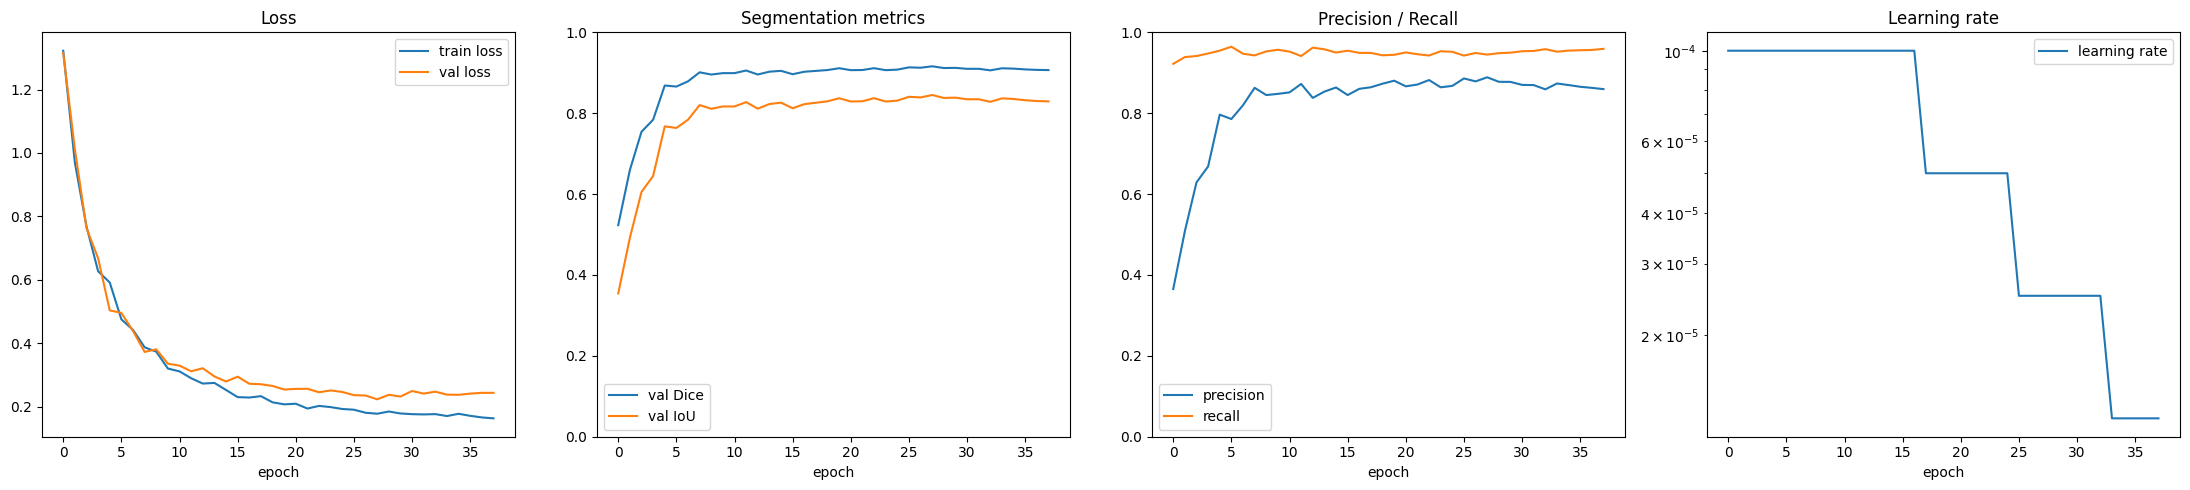

Training complete. Best val_dice = 0.9160
Loaded model from /content/drive/MyDrive/lava_fountain_runs/lava_unet_efficientnetb3_20260611_025803/best_model.pth (input_size=1536, threshold=0.5)

Threshold sweep (validation):
 threshold     dice      iou  precision   recall      fpr      fnr  area_error_fraction  height_error_px  width_error_px  centroid_error_px
      0.20 0.905147 0.826729   0.852267 0.965024 0.037902 0.034976             0.162181       123.823529      102.294118          19.429365
      0.25 0.908082 0.831640   0.860521 0.961209 0.035301 0.038791             0.148640        76.588235       61.470588          18.904383
      0.30 0.910415 0.835562   0.867551 0.957735 0.033130 0.042265             0.137094        62.352941       44.117647          18.420474
      0.35 0.912272 0.838696   0.873650 0.954468 0.031277 0.045532             0.126934        60.588235       33.470588          18.037629
      0.40 0.913739 0.841179   0.879026 0.951306 0.029664 0.048694            

In [19]:
if __name__ == "__main__":
    model, run_dir, used_threshold = main(CONFIG, frames_df, DATASET_ROOT)
    print(f"\nActive threshold: {used_threshold}")
    print("Bring predicted masks back into FountainLabeller from:")
    print(f"  {run_dir / 'predictions_all_frames' / 'masks'}")
    if CONFIG["export_for_labeller"]:
        print(f"  {run_dir / 'predictions_all_frames' / 'for_labeller' / 'masks' / 'all'}")